# Preset output exploration

This notebook compares the six stages from unconstrained randomness to harmonic lock-in. It reads the generated metric CSVs and MIDI files rather than regenerating them, so the analysis describes the exact saved outputs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pretty_midi

PRESET_ORDER = [
    'raw_random',
    'range_random',
    'tuning_center_only',
    'harmonic_social_tuning',
    'ambient_harmony',
    'locked_in',
]

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'exponential_random_orchestra').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the repository.')

ROOT = find_repo_root()
OUTPUT = ROOT / 'exponential_random_orchestra' / 'output'
DATA_DIR = OUTPUT / 'data'
MIDI_DIR = OUTPUT / 'midi'
OUTPUT

PosixPath('/workspaces/ExponentialRandomMusic/exponential_random_orchestra/output')

## Load metrics

Each row represents one simulation timestep. Sustained notes remain active in later rows, so these metrics describe the sounding texture rather than only note onsets.

In [2]:
frames = []
for preset in PRESET_ORDER:
    path = DATA_DIR / f'{preset}_metrics.csv'
    frame = pd.read_csv(path)
    frame['preset'] = preset
    frames.append(frame)

metrics = pd.concat(frames, ignore_index=True)
metrics.head()

,time,active_count,pitch_class_entropy,average_consonance,average_tuning_score,preset
0,0.00,1,-0.000000,NaN,-2.0,raw_random
1,0.25,1,-0.000000,NaN,-2.0,raw_random
2,0.50,1,-0.000000,NaN,-2.0,raw_random
3,0.75,1,-0.000000,NaN,3.0,raw_random
4,1.00,2,0.693147,-2.1625,1.0,raw_random


In [3]:
summary = (
    metrics.groupby('preset', sort=False)
    .agg(
        mean_active=('active_count', 'mean'),
        mean_entropy=('pitch_class_entropy', 'mean'),
        entropy_std=('pitch_class_entropy', 'std'),
        mean_consonance=('average_consonance', 'mean'),
        consonance_std=('average_consonance', 'std'),
        mean_tuning=('average_tuning_score', 'mean'),
    )
    .reindex(PRESET_ORDER)
)
summary.round(3)

,mean_active,mean_entropy,entropy_std,mean_consonance,consonance_std,mean_tuning
preset,,,,,,
raw_random,5.000,1.409,0.388,0.244,0.598,0.636
range_random,5.000,1.380,0.320,0.358,0.736,0.555
tuning_center_only,4.867,1.116,0.351,1.061,0.822,1.920
harmonic_social_tuning,4.992,0.517,0.297,2.510,0.254,2.596
ambient_harmony,4.625,0.064,0.199,2.744,0.188,2.599
locked_in,4.892,0.006,0.064,2.781,0.139,1.200


A useful first check is whether the progression has the intended shape: entropy should generally fall as constraints strengthen, while consonance and tuning-center attraction should rise. `locked_in` is expected to have very low entropy.

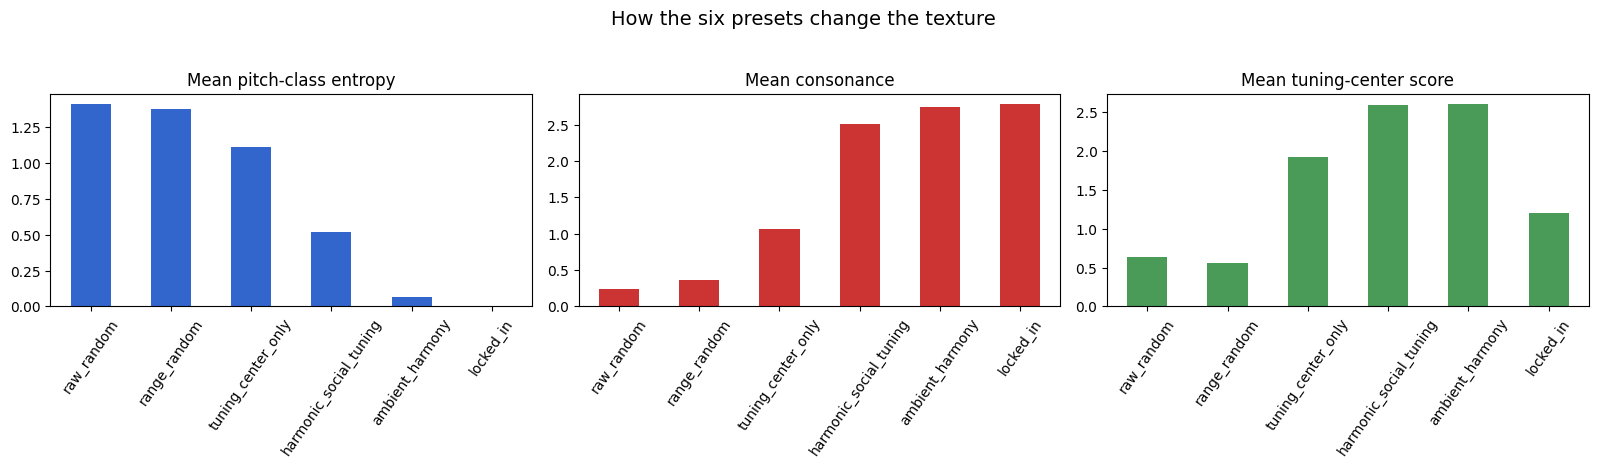

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
columns = [
    ('mean_entropy', 'Mean pitch-class entropy', '#3366cc'),
    ('mean_consonance', 'Mean consonance', '#cc3333'),
    ('mean_tuning', 'Mean tuning-center score', '#4b9b58'),
]
for axis, (column, title, color) in zip(axes, columns):
    summary[column].plot.bar(ax=axis, color=color)
    axis.set_title(title)
    axis.set_xlabel('')
    axis.tick_params(axis='x', rotation=55)
fig.suptitle('How the six presets change the texture', y=1.03, fontsize=14)
fig.tight_layout()

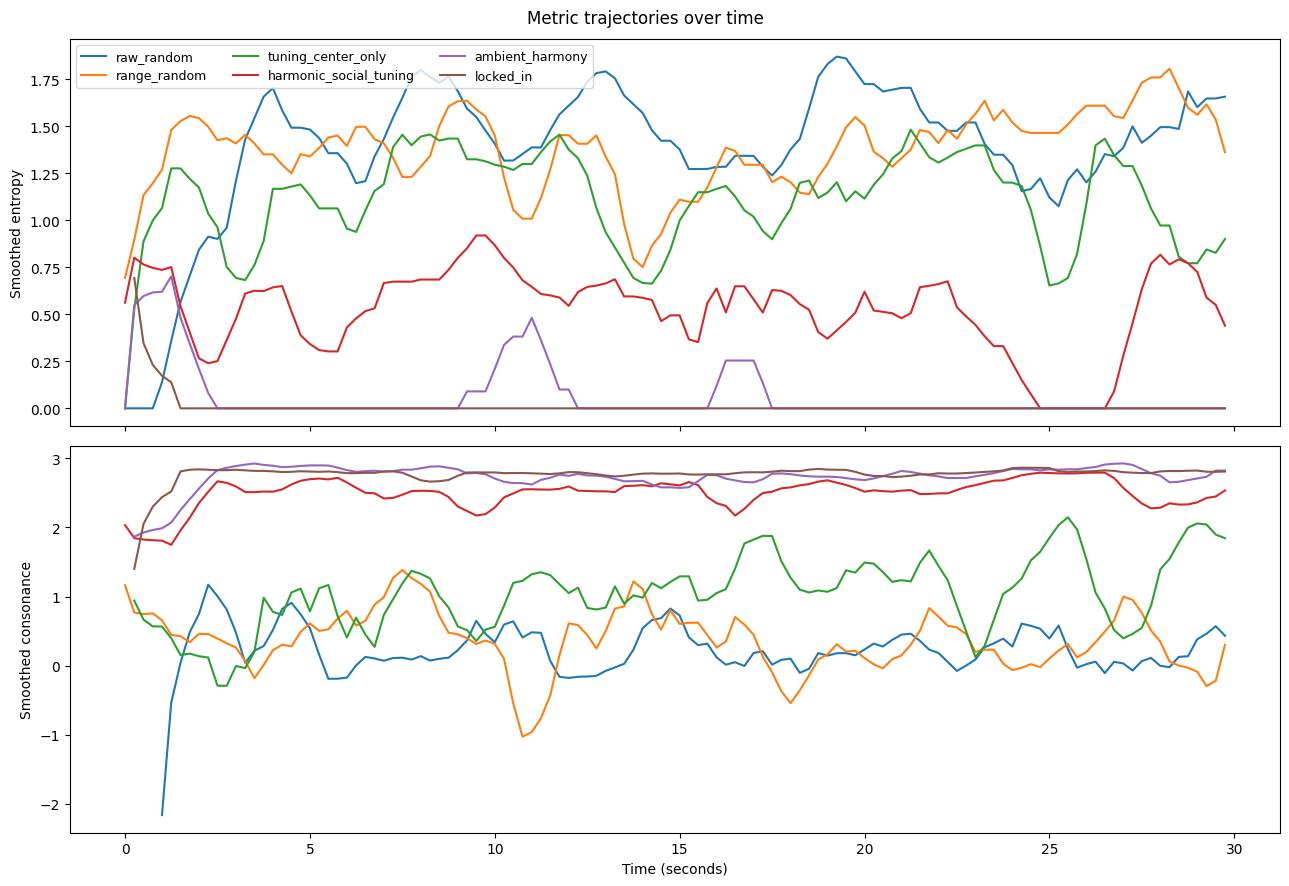

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for preset in PRESET_ORDER:
    subset = metrics[metrics['preset'] == preset]
    axes[0].plot(subset['time'], subset['pitch_class_entropy'].rolling(5, min_periods=1).mean(), label=preset)
    axes[1].plot(subset['time'], subset['average_consonance'].rolling(5, min_periods=1).mean(), label=preset)
axes[0].set_ylabel('Smoothed entropy')
axes[1].set_ylabel('Smoothed consonance')
axes[1].set_xlabel('Time (seconds)')
axes[0].legend(ncol=3, fontsize=9)
fig.suptitle('Metric trajectories over time')
fig.tight_layout()

## Inspect MIDI content

The table below checks that every clip has eight tracks and summarizes note density and register.

In [6]:
midi_rows = []
midi_objects = {}
for preset in PRESET_ORDER:
    midi = pretty_midi.PrettyMIDI(str(MIDI_DIR / f'{preset}.mid'))
    midi_objects[preset] = midi
    notes = [note for instrument in midi.instruments for note in instrument.notes]
    midi_rows.append({
        'preset': preset,
        'tracks': len(midi.instruments),
        'notes': len(notes),
        'duration_seconds': midi.get_end_time(),
        'lowest_pitch': min(note.pitch for note in notes),
        'highest_pitch': max(note.pitch for note in notes),
        'mean_velocity': np.mean([note.velocity for note in notes]),
    })
pd.DataFrame(midi_rows).set_index('preset').round(2)

,tracks,notes,duration_seconds,lowest_pitch,highest_pitch,mean_velocity
preset,,,,,,
raw_random,8,222,30.0,36,96,61.12
range_random,8,222,30.0,28,96,60.50
tuning_center_only,8,227,30.0,29,96,59.20
harmonic_social_tuning,8,255,30.0,30,93,60.58
ambient_harmony,8,216,30.0,33,94,59.93
locked_in,8,234,30.0,49,85,61.12


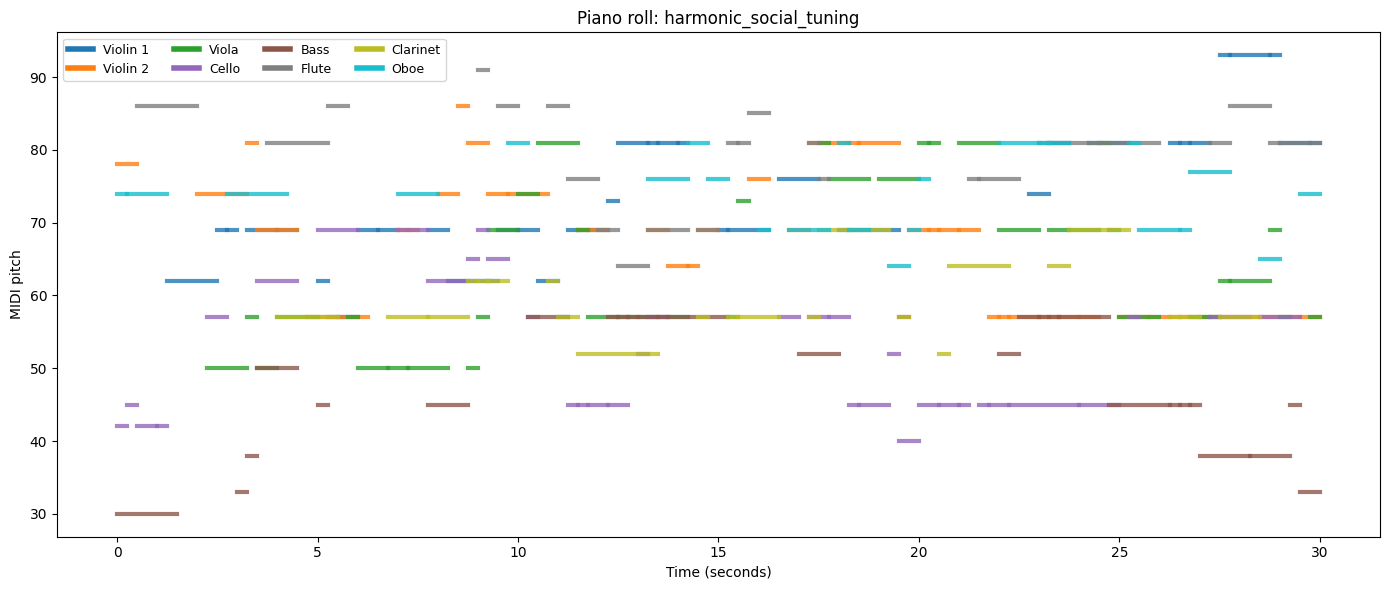

In [7]:
selected_preset = 'harmonic_social_tuning'
midi = midi_objects[selected_preset]
fig, axis = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(midi.instruments)))
for instrument_id, (instrument, color) in enumerate(zip(midi.instruments, colors)):
    for note in instrument.notes:
        axis.plot([note.start, note.end], [note.pitch, note.pitch], color=color, linewidth=3, alpha=0.8)
    axis.plot([], [], color=color, linewidth=4, label=instrument.name)
axis.set(xlabel='Time (seconds)', ylabel='MIDI pitch', title=f'Piano roll: {selected_preset}')
axis.legend(ncol=4, fontsize=9)
fig.tight_layout()

## Questions for the next iteration

- Does `ambient_harmony` collapse too aggressively compared with the intended slow harmonic cloud?
- Is the distinction between `raw_random` and `range_random` audible as well as measurable?
- Does `harmonic_social_tuning` retain enough pitch-class variety to sound tuning-like rather than chordal?
- Should metrics weight sustained duration, velocity, or instrumental section?